# GliZNet Forward Pass — Cosine Similarity at Each Stage

Step-by-step visualization of how label and text representations evolve through the aggregator:

1. **Raw embeddings** — DeBERTa output (label `[LAB]` tokens vs CLS/text tokens)
2. **Aggregated labels** — After gathering `[LAB]` token embeddings (identical to raw when 1 token per label)
3. **Enriched labels** — After `LabelContextAttention` (cooperative routing)
4. **Text representations** — Label-specific text pooling via learned attention (the big transformation)
5. **Bilinear scores** — Final logits from `BilinearScoring(text_repr, label_emb)`

**Three comparison axes:**
- **Label ↔ Label**: How similar are label embeddings to each other? Do true labels cluster?
- **Text ↔ Text**: How similar are label-conditioned text poolings? (Expected: high, since same input text)
- **Label ↔ Text**: cos(text_repr_i, label_i) — the cross-modal alignment the bilinear head amplifies

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

from gliznet import GliZNetForSequenceClassification, GliZNETTokenizer

# Use cuda:1 if available (cuda:0 is busy with training), else CPU
if torch.cuda.device_count() > 1:
    DEVICE = "cuda:1"
elif torch.cuda.is_available():
    free_mem = torch.cuda.mem_get_info(0)[0] / 1e9
    DEVICE = "cuda:0" if free_mem > 2 else "cpu"
else:
    DEVICE = "cpu"

MODEL_PATH = "../results/deberta-v3-base_20260518_090859/checkpoint-36000"

model = GliZNetForSequenceClassification.from_pretrained(MODEL_PATH).to(DEVICE).eval()
tokenizer = GliZNETTokenizer.from_pretrained(MODEL_PATH)

print(f"Device: {DEVICE}")
print(f"Model loaded from: {MODEL_PATH}")
print(f"Hidden size: {model.aggregator.hidden_size}")
print(f"Scoring: {model.aggregator.scoring.__class__.__name__}")
print(f"Label enrichment: {model.aggregator.label_context is not None}")

Loading weights:   0%|          | 0/209 [00:00<?, ?it/s]

Device: cuda:1
Model loaded from: ../results/deberta-v3-base_20260518_090859/checkpoint-36000
Hidden size: 768
Scoring: BilinearScoring
Label enrichment: True


In [2]:
# Define a sample text with labels (mix of true and false)
text = "New research shows that moderate coffee consumption may reduce the risk of Alzheimer's disease by up to 30%."
labels = ["medical_research", "nutrition_advice", "drug_development", "disease_prevention", "public_health_policy"]
expected = [True, False, False, True, False]

text = "After years of training and countless sacrifices, the athlete finally stood on the Olympic podium, tears streaming down her face as the national anthem played."
labels = ["athletic_achievement", "personal_sacrifice", "patriotism", "emotional_moment", "celebrity_gossip", "sports_injury", "political_protest", "entertainment_review", "historical_analysis", "travel_experience"]
expected = [True, True, True, True, False, False, False, False, False, False]

# Tokenize
batch = tokenizer([(text, labels)], return_tensors="pt")
batch = {k: v.to(DEVICE) for k, v in batch.items()}

print(f"Input shape: {batch['input_ids'].shape}")
print(f"Labels: {labels}")
print(f"\nExpected true:  {[l for l, e in zip(labels, expected) if e]}")
print(f"Expected false: {[l for l, e in zip(labels, expected) if not e]}")

Input shape: torch.Size([1, 70])
Labels: ['athletic_achievement', 'personal_sacrifice', 'patriotism', 'emotional_moment', 'celebrity_gossip', 'sports_injury', 'political_protest', 'entertainment_review', 'historical_analysis', 'travel_experience']

Expected true:  ['athletic_achievement', 'personal_sacrifice', 'patriotism', 'emotional_moment']
Expected false: ['celebrity_gossip', 'sports_injury', 'political_protest', 'entertainment_review', 'historical_analysis', 'travel_experience']


## Stage 1: Raw DeBERTa Embeddings

The encoder produces hidden states for ALL tokens (text + labels) in a single forward pass. At this stage, label tokens and text tokens share the same representational space — we measure cosine similarity between each label's `[LAB]` token and:
- The `[CLS]` token (global text summary)
- All text tokens (local evidence)

In [3]:
@torch.no_grad()
def get_all_stages(model, batch, labels):
    """Run the forward pass step by step, capturing intermediate representations."""
    input_ids = batch["input_ids"]
    attention_mask = batch["attention_mask"]
    lmask = batch["lmask"]
    
    # Stage 1: Raw encoder output
    encoder_output = model.backbone(input_ids=input_ids, attention_mask=attention_mask)
    hidden_states = encoder_output.last_hidden_state  # (1, L, D)
    
    agg = model.aggregator
    B, L, D = hidden_states.shape
    
    # Normalize (as the aggregator does)
    hidden_states_norm = F.normalize(hidden_states, p=2, dim=-1)
    
    # Identify positions
    lab_token_mask = input_ids == agg.lab_token_id
    text_mask = (lmask == 0) & (attention_mask == 1) & (~lab_token_mask)
    
    # CLS token (position 0)
    cls_emb = hidden_states_norm[0, 0]  # (D,)
    
    # Text token embeddings
    text_positions = text_mask[0].nonzero(as_tuple=True)[0]
    text_embs = hidden_states_norm[0, text_positions]  # (T, D)
    
    # Raw label token embeddings (before aggregation)
    lab_positions = lab_token_mask[0].nonzero(as_tuple=True)[0]
    raw_label_embs = hidden_states_norm[0, lab_positions]  # (K, D)
    
    # Stage 2: Aggregated labels (gathered from [LAB] positions)
    aggregated_labels, all_batch_ids, all_label_ids, max_k = agg.aggregate_labels(
        input_ids, hidden_states_norm
    )
    # Note: aggregate_labels applies dropout — in eval mode this is identity
    agg_label_embs = F.normalize(aggregated_labels, p=2, dim=-1)  # (K, D)
    
    # Build dense for context attention
    dense_labels = aggregated_labels.new_zeros(B, max_k, D)
    dense_labels[all_batch_ids, all_label_ids - 1] = aggregated_labels
    
    # Stage 3: Enriched labels (after LabelContextAttention)
    if agg.label_context is not None:
        label_mask = torch.zeros(B, max_k, dtype=torch.bool, device=hidden_states.device)
        label_mask[all_batch_ids, all_label_ids - 1] = True
        # Round 1 text pooling
        dense_text_r1 = agg._text_repr_dense(dense_labels, hidden_states_norm, text_mask)
        # Enrichment
        dense_labels_enriched = agg.label_context(dense_labels, dense_text_r1, label_mask)
        enriched_label_embs = F.normalize(
            dense_labels_enriched[all_batch_ids, all_label_ids - 1], p=2, dim=-1
        )
        # Update dense for final text repr
        dense_labels = dense_labels_enriched
        aggregated_labels = dense_labels_enriched[all_batch_ids, all_label_ids - 1]
    else:
        enriched_label_embs = agg_label_embs
    
    # Stage 4: Text representations (label-specific attention pooling)
    agg_text_dense = agg._text_repr_dense(dense_labels, hidden_states_norm, text_mask)
    text_repr_embs = F.normalize(
        agg_text_dense[all_batch_ids, all_label_ids - 1], p=2, dim=-1
    )  # (K, D)
    
    # Stage 5: Bilinear scores
    text_for_scoring = agg_text_dense[all_batch_ids, all_label_ids - 1]
    logits = agg.scoring(text_for_scoring, aggregated_labels)
    scores = torch.sigmoid(logits).squeeze(-1)  # (K,)
    
    return {
        "cls_emb": cls_emb,
        "text_embs": text_embs,
        "text_positions": text_positions,
        "raw_label_embs": raw_label_embs,
        "agg_label_embs": agg_label_embs,
        "enriched_label_embs": enriched_label_embs,
        "text_repr_embs": text_repr_embs,
        "logits": logits.squeeze(-1),
        "scores": scores,
        "labels": labels,
    }

stages = get_all_stages(model, batch, labels)
print("All stages captured.")
print(f"  Raw label embs:      {stages['raw_label_embs'].shape}")
print(f"  Aggregated labels:   {stages['agg_label_embs'].shape}")
print(f"  Enriched labels:     {stages['enriched_label_embs'].shape}")
print(f"  Text representations:{stages['text_repr_embs'].shape}")
print(f"  Text tokens:         {stages['text_embs'].shape}")

All stages captured.
  Raw label embs:      torch.Size([10, 768])
  Aggregated labels:   torch.Size([10, 768])
  Enriched labels:     torch.Size([10, 768])
  Text representations:torch.Size([10, 768])
  Text tokens:         torch.Size([30, 768])


In [4]:
def cos_sim(a, b):
    """Cosine similarity between vectors/matrices."""
    a = F.normalize(a, p=2, dim=-1)
    b = F.normalize(b, p=2, dim=-1)
    return (a @ b.T).cpu().numpy()


def plot_stage_heatmap(sim_matrix, row_labels, col_label, title, ax, vmin=-1, vmax=1):
    """Plot a cosine similarity heatmap."""
    sns.heatmap(
        sim_matrix, ax=ax, vmin=vmin, vmax=vmax, cmap="RdBu_r",
        xticklabels=[col_label] if isinstance(col_label, str) else col_label,
        yticklabels=row_labels,
        annot=True, fmt=".3f", annot_kws={"size": 9},
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title(title, fontsize=11, fontweight="bold")

print("Helpers ready.")

Helpers ready.


## Label Embeddings vs [CLS] Token

How each label's `[LAB]` embedding relates to the `[CLS]` token (global text summary) at each stage.

Note: CLS captures general text semantics — higher similarity does NOT mean "this label is correct". It just shows which labels are directionally aligned with the text representation.

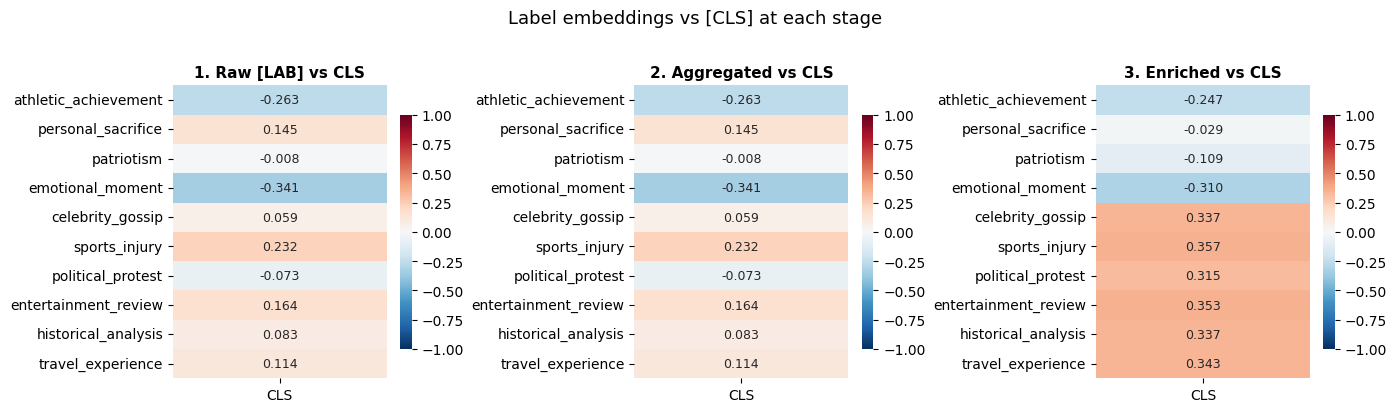


Label                        Raw    Agg  Enriched
──────────────────────────────────────────────────
athletic_achievement      -0.263 -0.263    -0.247
personal_sacrifice         0.145  0.145    -0.029
patriotism                -0.008 -0.008    -0.109
emotional_moment          -0.341 -0.341    -0.310
celebrity_gossip           0.059  0.059     0.337
sports_injury              0.232  0.232     0.357
political_protest         -0.073 -0.073     0.315
entertainment_review       0.164  0.164     0.353
historical_analysis        0.083  0.083     0.337
travel_experience          0.114  0.114     0.343


In [5]:
cls = stages["cls_emb"].unsqueeze(0)  # (1, D)

sim_raw_cls = cos_sim(stages["raw_label_embs"], cls)       # (K, 1)
sim_agg_cls = cos_sim(stages["agg_label_embs"], cls)       # (K, 1)
sim_enr_cls = cos_sim(stages["enriched_label_embs"], cls)  # (K, 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

plot_stage_heatmap(sim_raw_cls, labels, "CLS", "1. Raw [LAB] vs CLS", axes[0])
plot_stage_heatmap(sim_agg_cls, labels, "CLS", "2. Aggregated vs CLS", axes[1])
plot_stage_heatmap(sim_enr_cls, labels, "CLS", "3. Enriched vs CLS", axes[2])

plt.suptitle("Label embeddings vs [CLS] at each stage", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n{'Label':<25} {'Raw':>6} {'Agg':>6} {'Enriched':>9}")
print("─" * 50)
for i, (lbl, exp) in enumerate(zip(labels, expected)):
    print(f"{lbl:<25} {sim_raw_cls[i,0]:>6.3f} {sim_agg_cls[i,0]:>6.3f} {sim_enr_cls[i,0]:>9.3f}")

## Cosine Similarity: Labels vs All Text Tokens at Each Stage

This shows how each label's attention over text tokens sharpens through the pipeline.

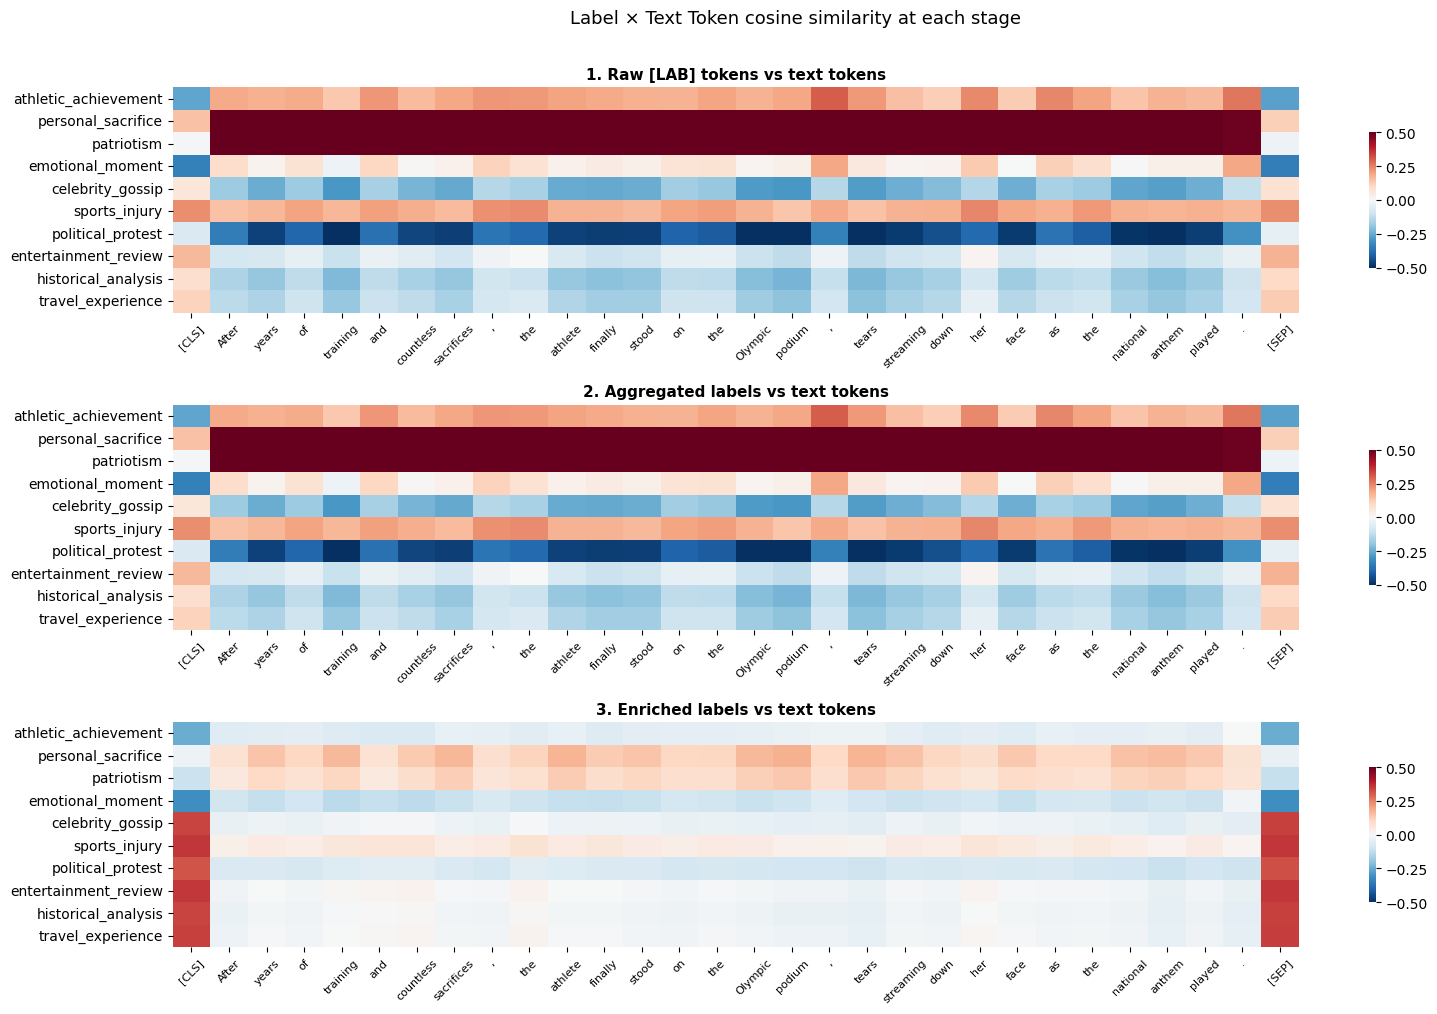

In [6]:
# Get text token strings for x-axis labels
token_ids = batch["input_ids"][0, stages["text_positions"]].cpu().tolist()
token_strs = tokenizer.tokenizer.convert_ids_to_tokens(token_ids)
# Shorten for display
token_strs = [t.replace("▁", "")[:12] for t in token_strs]

text_embs = stages["text_embs"]  # (T, D)

# Similarity matrices: labels × text tokens
sim_raw_text = cos_sim(stages["raw_label_embs"], text_embs)       # (K, T)
sim_agg_text = cos_sim(stages["agg_label_embs"], text_embs)       # (K, T)
sim_enr_text = cos_sim(stages["enriched_label_embs"], text_embs)  # (K, T)

fig, axes = plt.subplots(3, 1, figsize=(16, 10))

for ax, sim, title in zip(axes, 
    [sim_raw_text, sim_agg_text, sim_enr_text],
    ["1. Raw [LAB] tokens vs text tokens",
     "2. Aggregated labels vs text tokens",
     "3. Enriched labels vs text tokens"]):
    sns.heatmap(
        sim, ax=ax, cmap="RdBu_r", vmin=-0.5, vmax=0.5,
        xticklabels=token_strs, yticklabels=labels,
        cbar_kws={"shrink": 0.6},
    )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", rotation=45, labelsize=8)

plt.suptitle("Label × Text Token cosine similarity at each stage", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Pairwise Similarities at Each Stage

Three comparison types:
1. **Label ↔ Label** — Do label embeddings cluster by true/false?
2. **Text ↔ Text** — How similar are the label-conditioned text poolings to each other? (Same input text → naturally high)
3. **Label ↔ Text (cross)** — cos(text_repr_i, enriched_label_i) — the signal the bilinear head uses

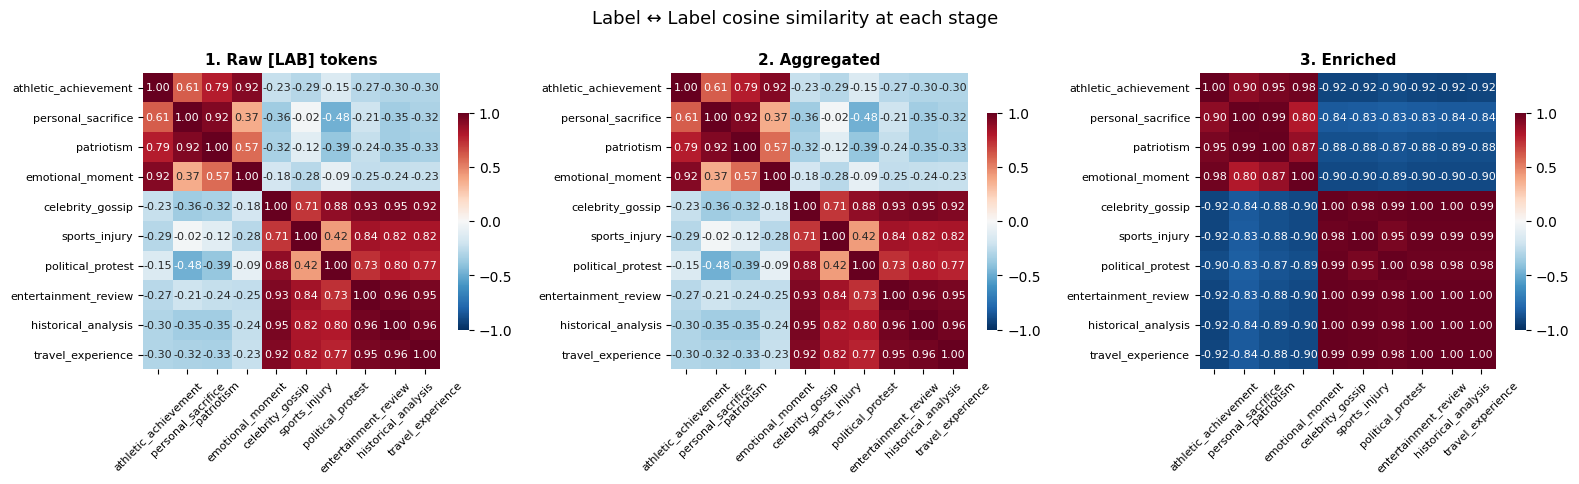

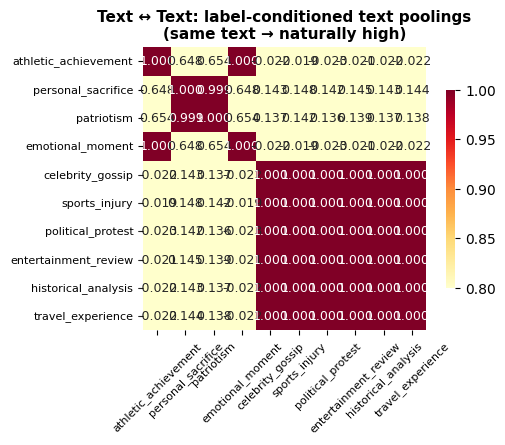

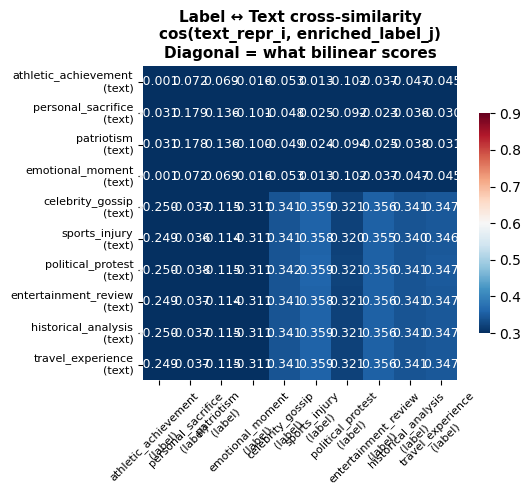


Diagonal (matched pairs) — this is what the bilinear head operates on:
Label                     cos(text_i, label_i)   Expected
──────────────────────────────────────────────────────────
athletic_achievement                   -0.0007       TRUE
personal_sacrifice                      0.1786       TRUE
patriotism                              0.1357       TRUE
emotional_moment                       -0.0156       TRUE
celebrity_gossip                        0.3415      FALSE
sports_injury                           0.3583      FALSE
political_protest                       0.3214      FALSE
entertainment_review                    0.3555      FALSE
historical_analysis                     0.3408      FALSE
travel_experience                       0.3468      FALSE


In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# 1. LABEL ↔ LABEL: How similar are label embeddings to each other?
# ──────────────────────────────────────────────────────────────────────────────
sim_ll_raw = cos_sim(stages["raw_label_embs"], stages["raw_label_embs"])
sim_ll_agg = cos_sim(stages["agg_label_embs"], stages["agg_label_embs"])
sim_ll_enr = cos_sim(stages["enriched_label_embs"], stages["enriched_label_embs"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, sim, title in zip(axes,
    [sim_ll_raw, sim_ll_agg, sim_ll_enr],
    ["1. Raw [LAB] tokens", "2. Aggregated", "3. Enriched"]):
    sns.heatmap(
        sim, ax=ax, vmin=-1, vmax=1, cmap="RdBu_r",
        xticklabels=labels, yticklabels=labels,
        annot=True, fmt=".2f", annot_kws={"size": 8},
        square=True, cbar_kws={"shrink": 0.7},
    )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0, labelsize=8)

plt.suptitle("Label ↔ Label cosine similarity at each stage", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# 2. TEXT ↔ TEXT: How similar are label-conditioned text poolings to each other?
#    (Expected: high — same input text pooled with slightly different attention)
# ──────────────────────────────────────────────────────────────────────────────
sim_tt = cos_sim(stages["text_repr_embs"], stages["text_repr_embs"])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    sim_tt, ax=ax, vmin=0.8, vmax=1.0, cmap="YlOrRd",
    xticklabels=labels, yticklabels=labels,
    annot=True, fmt=".3f", annot_kws={"size": 9},
    square=True, cbar_kws={"shrink": 0.7},
)
ax.set_title("Text ↔ Text: label-conditioned text poolings\n(same text → naturally high)", 
             fontsize=11, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# 3. LABEL ↔ TEXT (cross): cos(text_repr_i, enriched_label_j) — full cross matrix
#    Diagonal = the signal bilinear head uses. Off-diagonal = cross-label confusion.
# ──────────────────────────────────────────────────────────────────────────────
sim_lt = cos_sim(stages["text_repr_embs"], stages["enriched_label_embs"])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    sim_lt, ax=ax, vmin=0.3, vmax=0.9, cmap="RdBu_r",
    xticklabels=[f"{l}\n(label)" for l in labels],
    yticklabels=[f"{l}\n(text)" for l in labels],
    annot=True, fmt=".3f", annot_kws={"size": 9},
    square=True, cbar_kws={"shrink": 0.7},
)
ax.set_title("Label ↔ Text cross-similarity\ncos(text_repr_i, enriched_label_j)\nDiagonal = what bilinear scores", 
             fontsize=11, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

# Print diagonal summary
print("\nDiagonal (matched pairs) — this is what the bilinear head operates on:")
print(f"{'Label':<25} {'cos(text_i, label_i)':>20} {'Expected':>10}")
print("─" * 58)
for i, (lbl, exp) in enumerate(zip(labels, expected)):
    print(f"{lbl:<25} {sim_lt[i, i]:>20.4f} {'TRUE' if exp else 'FALSE':>10}")

## Final Scores: Text Representation × Label → Bilinear

The scoring head takes `(text_repr, enriched_label)` pairs and produces logits. We also show the cosine similarity between each label's text representation and the label itself — this is what the bilinear head "sees".

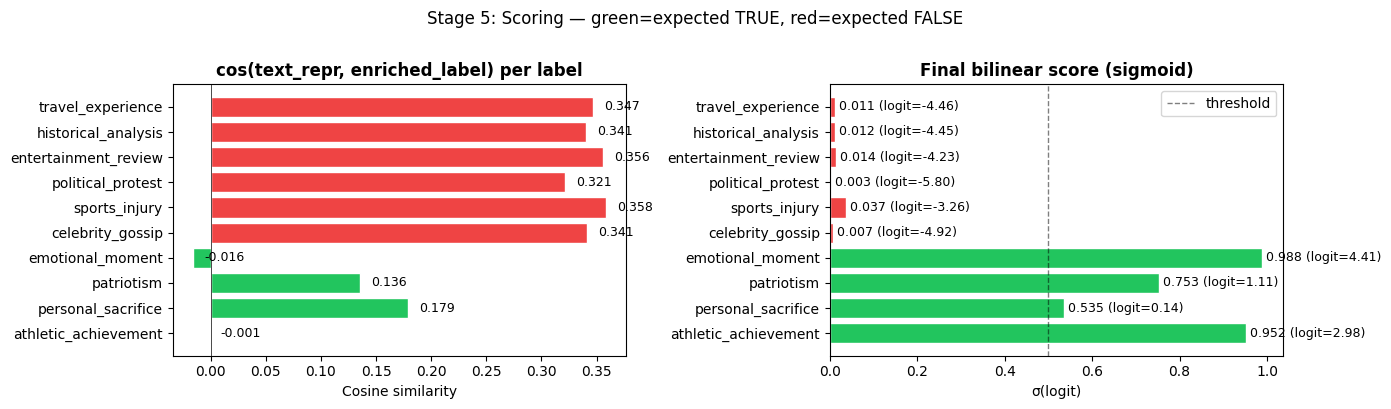


═════════════════════════════════════════════════════════════════════════════════════
FULL PROGRESSION: from raw encoder space → final decision
═════════════════════════════════════════════════════════════════════════════════════
Label                   lab↔CLS  enr↔CLS  txt↔lbl   Logit      σ   Exp
                          (raw) (enriched)  (cross)                     
─────────────────────────────────────────────────────────────────────────────────────
athletic_achievement     -0.263   -0.247   -0.001    2.98  0.952   T ✓
personal_sacrifice        0.145   -0.029    0.179    0.14  0.535   T ✓
patriotism               -0.008   -0.109    0.136    1.11  0.753   T ✓
emotional_moment         -0.341   -0.310   -0.016    4.41  0.988   T ✓
celebrity_gossip          0.059    0.337    0.341   -4.92  0.007   F ✓
sports_injury             0.232    0.357    0.358   -3.26  0.037   F ✓
political_protest        -0.073    0.315    0.321   -5.80  0.003   F ✓
entertainment_review      0.164    0.353  

In [8]:
# Cosine sim between text_repr and its corresponding label
text_repr = stages["text_repr_embs"]  # (K, D)
enr_labels = stages["enriched_label_embs"]  # (K, D)

# Pairwise cosine: each text_repr_i vs enriched_label_i
pair_cos = F.cosine_similarity(text_repr, enr_labels, dim=-1).cpu().numpy()

# Final bilinear scores
final_scores = stages["scores"].cpu().numpy()
final_logits = stages["logits"].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart: cosine sim (text_repr vs label)
colors = ["#22c55e" if e else "#ef4444" for e in expected]
axes[0].barh(labels, pair_cos, color=colors, edgecolor="white")
axes[0].set_xlabel("Cosine similarity")
axes[0].set_title("cos(text_repr, enriched_label) per label", fontweight="bold")
axes[0].axvline(0, color="black", lw=0.5)
for i, v in enumerate(pair_cos):
    axes[0].text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)

# Bar chart: final sigmoid scores
axes[1].barh(labels, final_scores, color=colors, edgecolor="white")
axes[1].set_xlabel("σ(logit)")
axes[1].set_title("Final bilinear score (sigmoid)", fontweight="bold")
axes[1].axvline(0.5, color="black", ls="--", lw=1, alpha=0.5, label="threshold")
axes[1].legend()
for i, (v, l) in enumerate(zip(final_scores, final_logits)):
    axes[1].text(v + 0.01, i, f"{v:.3f} (logit={l:.2f})", va="center", fontsize=9)

plt.suptitle("Stage 5: Scoring — green=expected TRUE, red=expected FALSE", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ── Unified progression table: trace how similarity evolves per label ──
print("\n" + "═" * 85)
print("FULL PROGRESSION: from raw encoder space → final decision")
print("═" * 85)
print(f"{'Label':<22} {'lab↔CLS':>8} {'enr↔CLS':>8} {'txt↔lbl':>8} {'Logit':>7} {'σ':>6} {'Exp':>5}")
print(f"{'':22} {'(raw)':>8} {'(enriched)':>10} {'(cross)':>8} {'':>7} {'':>6} {'':>5}")
print("─" * 85)
for i, (lbl, exp) in enumerate(zip(labels, expected)):
    mark = "✓" if (final_scores[i] > 0.5) == exp else "✗"
    print(f"{lbl:<22} {sim_raw_cls[i,0]:>8.3f} {sim_enr_cls[i,0]:>8.3f} "
          f"{pair_cos[i]:>8.3f} {final_logits[i]:>7.2f} {final_scores[i]:>6.3f} "
          f"{'T' if exp else 'F':>3} {mark}")
print("─" * 85)
print("lab↔CLS  = cos(label_emb, CLS)         — raw alignment in encoder space")
print("enr↔CLS  = cos(enriched_label, CLS)    — after LabelContextAttention")
print("txt↔lbl  = cos(text_repr_i, label_i)   — cross-modal (what bilinear amplifies)")
print("σ        = sigmoid(bilinear(text, label)) — final prediction")

## Summary: Full Similarity Trajectory

Single unified view showing how each label's "text vs label" cosine similarity evolves through the pipeline:
1. **Raw [LAB] ↔ CLS** — initial encoder alignment
2. **Enriched ↔ CLS** — after LabelContextAttention
3. **text_repr ↔ label** — after label-conditioned text attention pooling (the big jump)

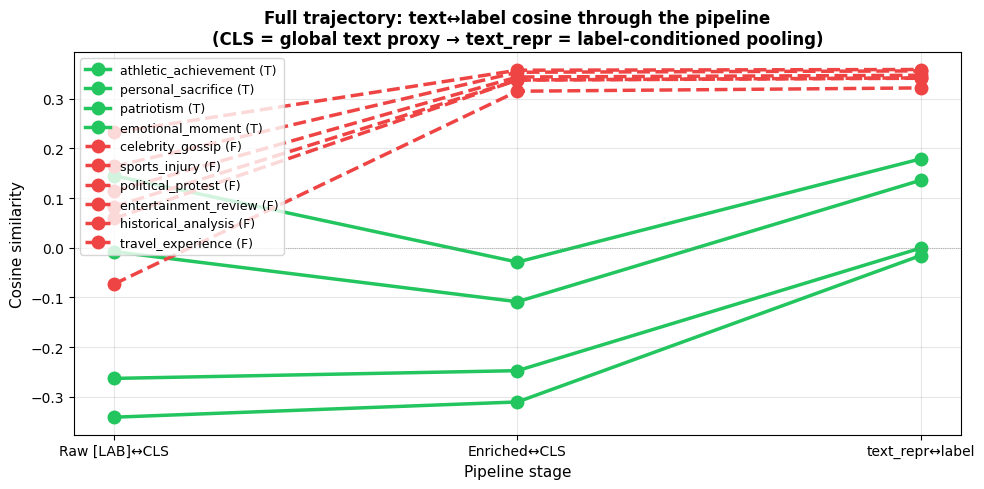


Label                    Raw↔CLS   Enr↔CLS   txt↔lbl  Δ(last)
────────────────────────────────────────────────────────────
athletic_achievement      -0.263    -0.247    -0.001   +0.246
personal_sacrifice         0.145    -0.029     0.179   +0.207
patriotism                -0.008    -0.109     0.136   +0.244
emotional_moment          -0.341    -0.310    -0.016   +0.294
celebrity_gossip           0.059     0.337     0.341   +0.004
sports_injury              0.232     0.357     0.358   +0.001
political_protest         -0.073     0.315     0.321   +0.007
entertainment_review       0.164     0.353     0.356   +0.003
historical_analysis        0.083     0.337     0.341   +0.004
travel_experience          0.114     0.343     0.347   +0.003


In [9]:
# ── Unified trajectory: text/CLS vs label at each stage ──
stage_names = ["Raw [LAB]↔CLS", "Enriched↔CLS", "text_repr↔label"]

# Build (K, 3) matrix: each row is one label's journey
pair_cos_diag = cos_sim(stages["text_repr_embs"], stages["enriched_label_embs"]).diagonal()
trajectory = np.column_stack([sim_raw_cls.flatten(), sim_enr_cls.flatten(), pair_cos_diag])

fig, ax = plt.subplots(figsize=(10, 5))

for i, (lbl, exp) in enumerate(zip(labels, expected)):
    color = "#22c55e" if exp else "#ef4444"
    ls = "-" if exp else "--"
    ax.plot(stage_names, trajectory[i], marker="o", color=color, ls=ls,
            lw=2.5, markersize=9, label=f"{lbl} ({'T' if exp else 'F'})")

ax.axhline(0, color="gray", lw=0.5, ls=":")
ax.set_ylabel("Cosine similarity", fontsize=11)
ax.set_xlabel("Pipeline stage", fontsize=11)
ax.set_title("Full trajectory: text↔label cosine through the pipeline\n"
             "(CLS = global text proxy → text_repr = label-conditioned pooling)",
             fontweight="bold", fontsize=12)
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print trajectory values
print(f"\n{'Label':<22} {'Raw↔CLS':>9} {'Enr↔CLS':>9} {'txt↔lbl':>9} {'Δ(last)':>8}")
print("─" * 60)
for i, (lbl, exp) in enumerate(zip(labels, expected)):
    delta = trajectory[i, 2] - trajectory[i, 1]
    print(f"{lbl:<22} {trajectory[i,0]:>9.3f} {trajectory[i,1]:>9.3f} "
          f"{trajectory[i,2]:>9.3f} {delta:>+8.3f}")